In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


  Matriks Jarak Terpendek Antar Node (Floyd-Warshall)
         A     B     C     D     E     F     G     H     #
   A     0     9     5    16     9     9     8    10     3
   B     9     0    14     8    15    17    16    16    12
   C     5    14     0    13     6     4     7     7     2
   D    16     8    13     0     7     9     8     8    13
   E     9    15     6     7     0     2     1     1     6
   F     9    17     4     9     2     0     3     3     6
   G     8    16     7     8     1     3     0     2     5
   H    10    16     7     8     1     3     2     0     7
   #     3    12     2    13     6     6     5     7     0

  Konfigurasi Open TSP
  Node tersedia : ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', '#']
  Jenis masalah : Open TSP (semua node dikunjungi, tidak kembali ke awal)
  Masukkan node awal  : H
  Masukkan node akhir : D
  Node wajib dilewati (pisah koma, kosong jika tidak ada): #

  Open TSP: H → D
  Wajib lewat : ['#']
  Semua node  : ['A', 'B', 'C', 'D', 'E'

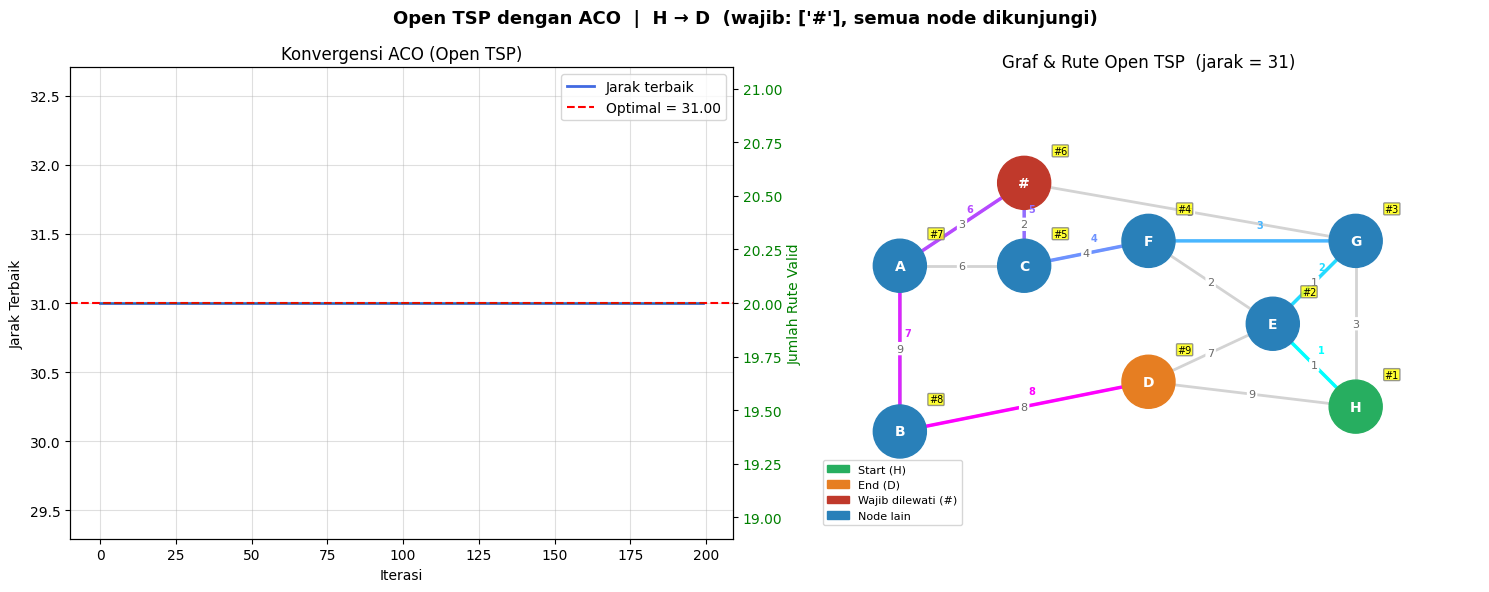


  Grafik disimpan sebagai 'hasil_aco_opentsp.png'


In [3]:
"""
=============================================================================
  Open Traveling Salesman Problem (Open TSP)
  dengan Ant Colony Optimization (ACO)

  Graf : A, B, C, D, E, F, G, H, #
  Kasus: - Start : H
         - End   : D
         - Wajib : Lewat node '#'
         - Semua node HARUS dikunjungi tepat satu kali (Open TSP)
         - Tidak perlu kembali ke titik awal (bukan siklus)
=============================================================================
"""

import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Seed untuk reproduksibilitas hasil
random.seed(42)
np.random.seed(42)

# =============================================================================
# 1. MEMBANGUN GRAF & MATRIKS JARAK
# =============================================================================

KOTA = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', '#']
N    = len(KOTA)
IDX  = {k: i for i, k in enumerate(KOTA)}
INF  = 1e9

dist = np.full((N, N), INF)
np.fill_diagonal(dist, 0)

# Edge graf (tidak berarah) sesuai gambar
EDGES = [
    ('#', 'A', 3), ('#', 'C', 2), ('#', 'G', 5),
    ('A', 'B', 9), ('A', 'C', 6),
    ('B', 'D', 8),
    ('C', 'F', 4),
    ('D', 'E', 7), ('D', 'H', 9),
    ('E', 'F', 2), ('E', 'G', 1), ('E', 'H', 1),
    ('G', 'H', 3),
]

for (u, v, w) in EDGES:
    i, j = IDX[u], IDX[v]
    dist[i][j] = w
    dist[j][i] = w

# -------------------------------------------------------------------------
# Floyd-Warshall: jarak terpendek antara semua pasangan node
# Diperlukan karena graf parsial (tidak semua node terhubung langsung)
# -------------------------------------------------------------------------
shortest = dist.copy()
for k in range(N):
    for i in range(N):
        if shortest[i][k] == INF:
            continue
        for j in range(N):
            if shortest[k][j] == INF:
                continue
            if shortest[i][k] + shortest[k][j] < shortest[i][j]:
                shortest[i][j] = shortest[i][k] + shortest[k][j]

if np.any(shortest == INF):
    raise RuntimeError("Graf tidak terhubung! Periksa kembali daftar edge.")

# Tampilkan matriks jarak terpendek
print("=" * 65)
print("  Matriks Jarak Terpendek Antar Node (Floyd-Warshall)")
print("=" * 65)
header = f"{'':>4}" + "".join(f"{k:>6}" for k in KOTA)
print(header)
for i, k in enumerate(KOTA):
    row = f"{k:>4}" + "".join(
        f"{'inf':>6}" if shortest[i][j] == INF else f"{shortest[i][j]:>6.0f}"
        for j in range(N)
    )
    print(row)

# =============================================================================
# 2. KONFIGURASI OPEN TSP
# =============================================================================

print("\n" + "=" * 65)
print("  Konfigurasi Open TSP")
print("=" * 65)
print(f"  Node tersedia : {KOTA}")
print(f"  Jenis masalah : Open TSP (semua node dikunjungi, tidak kembali ke awal)")

start_nama  = input("  Masukkan node awal  : ").strip().upper()
end_nama    = input("  Masukkan node akhir : ").strip().upper()
wajib_input = input("  Node wajib dilewati (pisah koma, kosong jika tidak ada): ").strip().upper()

wajib_list = [x.strip() for x in wajib_input.split(',')] if wajib_input else []

# Validasi input
for nama in [start_nama, end_nama] + wajib_list:
    if nama and nama not in IDX:
        raise ValueError(f"Node '{nama}' tidak ada dalam graf!")

START         = IDX[start_nama]
END           = IDX[end_nama]
WAJIB_INDICES = [IDX[w] for w in wajib_list]

# =============================================================================
# 3. PARAMETER ACO
# =============================================================================

N_ANTS = 20    # jumlah semut per iterasi
N_ITER = 200   # jumlah iterasi (lebih banyak karena Open TSP lebih kompleks)
ALPHA  = 1.0   # bobot feromon
BETA   = 2.0   # bobot visibilitas (1/jarak)
RHO    = 0.5   # laju penguapan feromon
Q      = 1.0   # konstanta deposit feromon

# Matriks feromon awal
pheromone = np.full((N, N), 0.1)
np.fill_diagonal(pheromone, 0.0)

# =============================================================================
# 4. FUNGSI-FUNGSI ACO
# =============================================================================

def hitung_jarak_tur(tur: list) -> float:
    """Menghitung total jarak rute menggunakan matriks shortest path."""
    return sum(shortest[tur[i]][tur[i+1]] for i in range(len(tur)-1))


def rute_valid(tur: list) -> bool:
    """
    Validasi rute untuk Open TSP:
    1. Dimulai dari START
    2. Diakhiri di END
    3. Semua node wajib dikunjungi
    4. Semua N node dikunjungi tepat satu kali
    """
    if not tur:
        return False
    if tur[0] != START:
        return False
    if tur[-1] != END:
        return False
    if not all(w in tur for w in WAJIB_INDICES):
        return False
    # Open TSP: semua node harus dikunjungi tepat satu kali
    if len(set(tur)) != N:
        return False
    return True


def pilih_kota_berikutnya(sekarang: int, dikunjungi: list) -> int | None:
    """
    Memilih node berikutnya secara probabilistik.

    Aturan khusus Open TSP:
    - END (D) hanya boleh dipilih jika semua node lain sudah dikunjungi
    - Node wajib (#) diprioritaskan jika semut mendekati akhir tur
    """
    belum_dikunjungi = [k for k in range(N) if not dikunjungi[k]]

    # Jika hanya END yang tersisa → paksa ke END
    if belum_dikunjungi == [END]:
        return END

    prob = np.zeros(N)
    for calon in range(N):
        if dikunjungi[calon]:
            continue

        # Larang memilih END jika masih ada node lain yang belum dikunjungi
        if calon == END and len(belum_dikunjungi) > 1:
            continue

        # Larang memilih END jika node wajib belum semua dikunjungi
        if calon == END and not all(dikunjungi[w] for w in WAJIB_INDICES):
            continue

        if shortest[sekarang][calon] < INF:
            tau = pheromone[sekarang][calon] ** ALPHA
            eta = (1.0 / shortest[sekarang][calon]) ** BETA
            prob[calon] = tau * eta

    total = prob.sum()
    if total == 0:
        # Fallback: pilih acak dari node yang belum dikunjungi (kecuali END)
        fallback = [k for k in range(N)
                    if not dikunjungi[k] and k != END]
        if fallback:
            return random.choice(fallback)
        # Jika tidak ada pilihan selain END
        return END if not dikunjungi[END] else None

    prob /= total
    return int(np.random.choice(N, p=prob))


def bangun_tur() -> list:
    """
    Seekor semut membangun rute Open TSP:
    - Mulai dari START
    - Kunjungi SEMUA node tepat satu kali
    - END hanya dikunjungi paling terakhir
    - Tidak kembali ke START
    """
    tur        = [START]
    dikunjungi = [False] * N
    dikunjungi[START] = True
    max_langkah = N * 4

    for _ in range(max_langkah):
        sekarang = tur[-1]

        # Cek apakah tur sudah selesai (semua node dikunjungi & di END)
        if sekarang == END and len(set(tur)) == N:
            break

        berikutnya = pilih_kota_berikutnya(sekarang, dikunjungi)
        if berikutnya is None:
            break

        tur.append(berikutnya)
        dikunjungi[berikutnya] = True

    return tur


def update_pheromone(semua_tur: list, semua_jarak: list):
    """
    Update feromon:
    1. Penguapan: tau *= (1 - rho)
    2. Deposit  : hanya rute VALID yang mendapat deposit feromon
                  deposit = Q / jarak (rute lebih pendek = feromon lebih banyak)
    """
    global pheromone
    pheromone *= (1 - RHO)
    for tur, jarak in zip(semua_tur, semua_jarak):
        if jarak == 0 or not rute_valid(tur):
            continue
        deposit = Q / jarak
        for i in range(len(tur) - 1):
            a, b = tur[i], tur[i+1]
            pheromone[a][b] += deposit
            pheromone[b][a] += deposit

# =============================================================================
# 5. LOOP UTAMA ACO
# =============================================================================

best_tur   = None
best_jarak = float('inf')
history    = []
valid_count_history = []

print("\n" + "=" * 65)
print(f"  Open TSP: {start_nama} → {end_nama}")
print(f"  Wajib lewat : {wajib_list or 'tidak ada'}")
print(f"  Semua node  : {KOTA} (wajib semua dikunjungi)")
print(f"  Parameter   : semut={N_ANTS}, iterasi={N_ITER}, α={ALPHA}, β={BETA}, ρ={RHO}")
print("=" * 65)

for it in range(N_ITER):
    semua_tur   = []
    semua_jarak = []
    valid_iter  = 0

    for _ in range(N_ANTS):
        tur   = bangun_tur()
        jarak = hitung_jarak_tur(tur)
        semua_tur.append(tur)
        semua_jarak.append(jarak)

        if rute_valid(tur):
            valid_iter += 1
            if jarak < best_jarak:
                best_jarak = jarak
                best_tur   = tur.copy()

    update_pheromone(semua_tur, semua_jarak)
    history.append(best_jarak if best_jarak < float('inf') else None)
    valid_count_history.append(valid_iter)

    if (it + 1) % 40 == 0:
        status = f"{best_jarak:.2f}" if best_jarak < float('inf') else "belum ditemukan"
        print(f"  Iterasi {it+1:>3d} | Jarak terbaik = {status} | "
              f"Rute valid = {valid_iter}/{N_ANTS}")

# =============================================================================
# 6. TAMPILKAN HASIL AKHIR
# =============================================================================

print("\n" + "=" * 65)
print("  HASIL OPEN TSP")
print("=" * 65)

if best_tur is None:
    print("  Rute tidak ditemukan.")
else:
    rute_nama = [KOTA[i] for i in best_tur]
    print(f"  Rute       : {' -> '.join(rute_nama)}")
    print(f"  Jarak total: {best_jarak:.2f}")
    print(f"  Node dikunjungi: {len(set(best_tur))}/{N} ({'✓ Semua' if len(set(best_tur))==N else '✗ Belum semua'})")
    print(f"  Wajib (#)  : {'✓ Dilewati' if IDX['#'] in best_tur else '✗ Tidak dilewati'}")
    print(f"  Open TSP   : {'✓ Valid (tidak kembali ke awal)' if best_tur[0] != best_tur[-1] else '✗ Kembali ke awal'}")

    print("\n  Detail segmen:")
    for i in range(len(best_tur) - 1):
        a, b   = best_tur[i], best_tur[i+1]
        jarak  = shortest[a][b]
        # Tandai jika ini jalur via Floyd-Warshall (bukan edge langsung)
        langsung = dist[a][b] < INF
        ket    = "" if langsung else " (via shortest path)"
        print(f"    {KOTA[a]:>2} -> {KOTA[b]:<2} : {jarak:.0f}{ket}")

print("=" * 65)

# =============================================================================
# 7. VISUALISASI
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(
    f"Open TSP dengan ACO  |  {start_nama} → {end_nama}  "
    f"(wajib: {wajib_list}, semua node dikunjungi)",
    fontsize=13, fontweight='bold'
)

# --- Plot 1: Grafik Konvergensi ---
ax1 = axes[0]
valid_history = [v for v in history if v is not None]
valid_iter_x  = [i for i, v in enumerate(history) if v is not None]

ax1.plot(valid_iter_x, valid_history, color='royalblue',
         linewidth=2, label='Jarak terbaik')
if best_jarak < float('inf'):
    ax1.axhline(y=best_jarak, color='red', linestyle='--',
                linewidth=1.5, label=f'Optimal = {best_jarak:.2f}')
ax1.set_title('Konvergensi ACO (Open TSP)')
ax1.set_xlabel('Iterasi')
ax1.set_ylabel('Jarak Terbaik')
ax1.legend()
ax1.grid(True, alpha=0.4)

# Tambahan: plot jumlah rute valid per iterasi (axis kanan)
ax1b = ax1.twinx()
ax1b.plot(valid_count_history, color='green', alpha=0.3,
          linewidth=1, label='Rute valid/iterasi')
ax1b.set_ylabel('Jumlah Rute Valid', color='green')
ax1b.tick_params(axis='y', labelcolor='green')

# --- Plot 2: Visualisasi Graf & Rute ---
ax2 = axes[1]

pos = {
    '#': (2.5, 4.2),
    'A': (1.0, 3.2),
    'B': (1.0, 1.2),
    'C': (2.5, 3.2),
    'D': (4.0, 1.8),
    'E': (5.5, 2.5),
    'F': (4.0, 3.5),
    'G': (6.5, 3.5),
    'H': (6.5, 1.5),
}

# Gambar semua edge (abu-abu)
for (u, v, w) in EDGES:
    x1, y1 = pos[u]
    x2, y2 = pos[v]
    ax2.plot([x1, x2], [y1, y2], color='lightgray', linewidth=2, zorder=1)
    mx, my = (x1+x2)/2, (y1+y2)/2
    ax2.text(mx, my, str(w), fontsize=8, ha='center', va='center',
             color='dimgray',
             bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none'))

# Gambar edge rute terbaik dengan panah berwarna
if best_tur:
    n_steps = len(best_tur) - 1
    cmap    = plt.cm.cool
    for i in range(n_steps):
        u_name = KOTA[best_tur[i]]
        v_name = KOTA[best_tur[i+1]]
        x1, y1 = pos[u_name]
        x2, y2 = pos[v_name]
        color  = cmap(i / max(n_steps - 1, 1))
        ax2.annotate(
            '', xy=(x2, y2), xytext=(x1, y1),
            arrowprops=dict(arrowstyle='->', color=color, lw=2.5),
            zorder=2
        )
        # Nomor urutan langkah
        mx, my = (x1+x2)/2 + 0.05, (y1+y2)/2 + 0.15
        ax2.text(mx, my, str(i+1), fontsize=7, color=color,
                 fontweight='bold', zorder=5)

# Gambar node
for nama, (x, y) in pos.items():
    if nama == start_nama:
        color = '#27ae60'    # hijau = start
    elif nama == end_nama:
        color = '#e67e22'    # oranye = end
    elif nama == '#':
        color = '#c0392b'    # merah = node wajib
    else:
        color = '#2980b9'    # biru = node biasa

    circle = plt.Circle((x, y), 0.32, color=color, zorder=3)
    ax2.add_patch(circle)
    ax2.text(x, y, nama, ha='center', va='center',
             fontsize=10, fontweight='bold', color='white', zorder=4)

    # Nomor urutan kunjungan
    if best_tur and IDX[nama] in best_tur:
        urutan = best_tur.index(IDX[nama]) + 1
        ax2.text(x + 0.35, y + 0.35, f'#{urutan}',
                 fontsize=7, color='black', zorder=6,
                 bbox=dict(boxstyle='round,pad=0.1', fc='yellow',
                           ec='gray', alpha=0.8))

ax2.set_xlim(0, 8)
ax2.set_ylim(0, 5.5)
ax2.set_aspect('equal')
ax2.axis('off')
ax2.set_title(f"Graf & Rute Open TSP  (jarak = {best_jarak:.0f})")

# Legend
legend_items = [
    mpatches.Patch(color='#27ae60', label=f'Start ({start_nama})'),
    mpatches.Patch(color='#e67e22', label=f'End ({end_nama})'),
    mpatches.Patch(color='#c0392b', label='Wajib dilewati (#)'),
    mpatches.Patch(color='#2980b9', label='Node lain'),
]
ax2.legend(handles=legend_items, loc='lower left', fontsize=8)

plt.tight_layout()
plt.savefig('hasil_aco_opentsp.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n  Grafik disimpan sebagai 'hasil_aco_opentsp.png'")